In [2]:
import os
import pygmt
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import bordado as bd
import boule as bl
import harmonica as hm
import verde as vd
import itertools
from scipy.interpolate import griddata

import spherical as sph

In [3]:
def save_fit_results(model, filename="fit_results"):
    attrs = {}
    for key in ["residuals_", "dipole_moments_", "window_centers_", "source_coordinates_"]:
        if hasattr(model, key):
            attrs[key] = getattr(model, key)
    np.savez(f"{filename}.npz", **attrs, allow_pickle=True)

def load_fit_results(model, filename="fit_results"):
    data = np.load(f"{filename}.npz", allow_pickle=True)
    for key in data.files:
        value = data[key]
        if key == "source_coordinates_":
            value = tuple(value)
        setattr(model, key, value)
    return model

def deg_to_km(spacing_km):
    spacing_deg = spacing_km / 111.11
    return spacing_deg

def save_predict_results(coordinates, prediction, filename="predict_results"):

    np.savez(
        f"{filename}.npz",
        coordinates=coordinates,
        prediction=prediction,
        allow_pickle=True,
    )


def load_predict_results(filename="predict_results"):

    data = np.load(f"{filename}.npz", allow_pickle=True)

    coordinates = data["coordinates"]
    prediction = data["prediction"]

    return coordinates, prediction


In [4]:
caminho = "../data/parana-basin-magnetic-processed.csv"

df = pd.read_csv(caminho, sep=',', comment="#")
df.columns = ['FID','ESTACAO','LINHA','X','Y','LATITUDE','LONGITUDE','DATA','HORA','GPSALT','BARO',
              'MAGBRU','MAGCOM','MAGBASE','MAGCOR','MAGNIV','MAGMIC','MAGIGRF','IGRF','MDT']

prefixos = ('19', '29', '39')
df = df[~df['LINHA'].astype(str).str.startswith(prefixos)].copy()

In [5]:
reducer = vd.BlockReduce(reduction=np.median, spacing= 0.0023) 

coordinates, mag= reducer.filter(
    (df.LONGITUDE, df.LATITUDE, df.GPSALT), df.MAGIGRF
)

coordinates, height = reducer.filter(
    (df.LONGITUDE, df.LATITUDE), df.GPSALT
)

lon, lat = coordinates

coordinates = (lon, lat, height)

/home/arthur/miniforge3/envs/spherical-eqs/lib/python3.12/site-packages/verde/blockreduce.py:179: FutureWarning: The provided callable <function median at 0x7f7a8c2072e0> is currently using DataFrameGroupBy.median. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "median" instead.
  blocked = pd.DataFrame(columns).groupby("block").aggregate(reduction)
/home/arthur/miniforge3/envs/spherical-eqs/lib/python3.12/site-packages/verde/blockreduce.py:236: FutureWarning: The provided callable <function median at 0x7f7a8c2072e0> is currently using DataFrameGroupBy.median. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "median" instead.
  grouped = table.groupby("block").aggregate(self.reduction)
/home/arthur/miniforge3/envs/spherical-eqs/lib/python3.12/site-packages/verde/blockreduce.py:179: FutureWarning: The provided callable <function median at 0x7f7a8c2072

In [6]:
inclination, declination = -25, -20 

grid_spacing = deg_to_km(1)
window_size = 1.5

grid_coord = bd.grid_coordinates((-56.8, -46.5, -25, -14), spacing= grid_spacing, non_dimensional_coords=500)

In [7]:
eqs_deep_00023_loaded = sph.EquivalentSourcesMagGeod(damping=1e2, depth=100e3)

eqs_deep_00023_loaded = load_fit_results(
    eqs_deep_00023_loaded,
    filename="eqs_deep_fit_00023"
)

predicted_deep = eqs_deep_00023_loaded.predict(grid_coord)

tfa_predicted_deep = hm.total_field_anomaly(
    predicted_deep,
    inclination,
    declination,
)

save_predict_results(
    grid_coord,
    predicted_deep,
    filename="eqs_deep_predict_grid_00023"
)

predicted_scatter_deep = eqs_deep_00023_loaded.predict(coordinates)

tfa_predicted_scatter_deep = hm.total_field_anomaly(
    predicted_scatter_deep,
    inclination,
    declination,
)

save_predict_results(
    coordinates,
    predicted_scatter_deep,
    filename="eqs_deep_predict_scatter_00023"
)


In [8]:
%%time
eqs_shallow_00023_loaded = sph.EquivalentSourcesMagGeodGB(
    block_size=grid_spacing,
    window_size=window_size,
    depth=9e3,
    damping=1e4
)

eqs_shallow_00023_loaded = load_fit_results(
    eqs_shallow_00023_loaded,
    filename="eqs_shallow_fit_00023"
)

predicted_shallow = eqs_shallow_00023_loaded.predict(grid_coord)

tfa_predicted_shallow = hm.total_field_anomaly(
    predicted_shallow,
    inclination,
    declination,
)

save_predict_results(
    grid_coord,
    predicted_shallow,
    filename="eqs_shallow_predict_grid_00023"
)

predicted_scatter_shallow = eqs_shallow_00023_loaded.predict(coordinates)

tfa_predicted_scatter_shallow = hm.total_field_anomaly(
    predicted_scatter_shallow,
    inclination,
    declination,
)

save_predict_results(
    coordinates,
    predicted_scatter_shallow,
    filename="eqs_shallow_predict_scatter_00023"
)

CPU times: user 11h 47min 33s, sys: 27.4 s, total: 11h 48min 1s
Wall time: 1h 33min 40s


In [9]:
%%time

b_predicted = vd.make_xarray_grid(
    grid_coord,
    predicted_deep,
    data_names=("be","bn","bu"),
    dims=("latitude", "longitude"),
    extra_coords_names="height",
)

b_predicted+= vd.make_xarray_grid(
    grid_coord,
    predicted_shallow,
    data_names=("be","bn","bu"),
    dims=("latitude", "longitude"),
    extra_coords_names="height",
)

CPU times: user 96.4 ms, sys: 0 ns, total: 96.4 ms
Wall time: 94.8 ms


In [18]:
tfa_grid = tfa_predicted_shallow + tfa_predicted_deep
tfa_scatter = tfa_predicted_scatter_deep + tfa_predicted_scatter_shallow

residuals_scatter = mag - tfa_scatter 

total_field_anomaly_predicted = vd.make_xarray_grid(
    grid_coord,
    tfa_grid,
    data_names="grid",
    dims=("latitude", "longitude"),
    extra_coords_names="height",
).grid

norm_b_grid = np.sqrt(b_predicted["be"]**2 + b_predicted["bn"]**2 + b_predicted["bu"]**2)

norm_b_predicted = vd.make_xarray_grid(
    grid_coord,
    norm_b_grid.data,
    data_names="grid",
    dims=("latitude", "longitude"),
    extra_coords_names="height",
).grid

In [12]:
shapefile_brasil = "../../../.cache/pooch//BR_UF_2022/BR_UF_2022.shp"


required_extensions = ['.shp', '.shx', '.dbf']
base_name = os.path.splitext(shapefile_brasil)[0]

missing_files = []
for ext in required_extensions:
    file_path = f"{base_name}{ext}"
    if not os.path.exists(file_path):
        missing_files.append(file_path)

if missing_files:
    print(f"Erro: Os seguintes arquivos obrigatórios estão faltando: {', '.join(missing_files)}")
    exit()


try:
    brasil = gpd.read_file(shapefile_brasil)
except Exception as e:
    print(f"Erro ao carregar o shapefile: {e}")
    exit()



brasil_reduc = brasil.simplify(0.05)

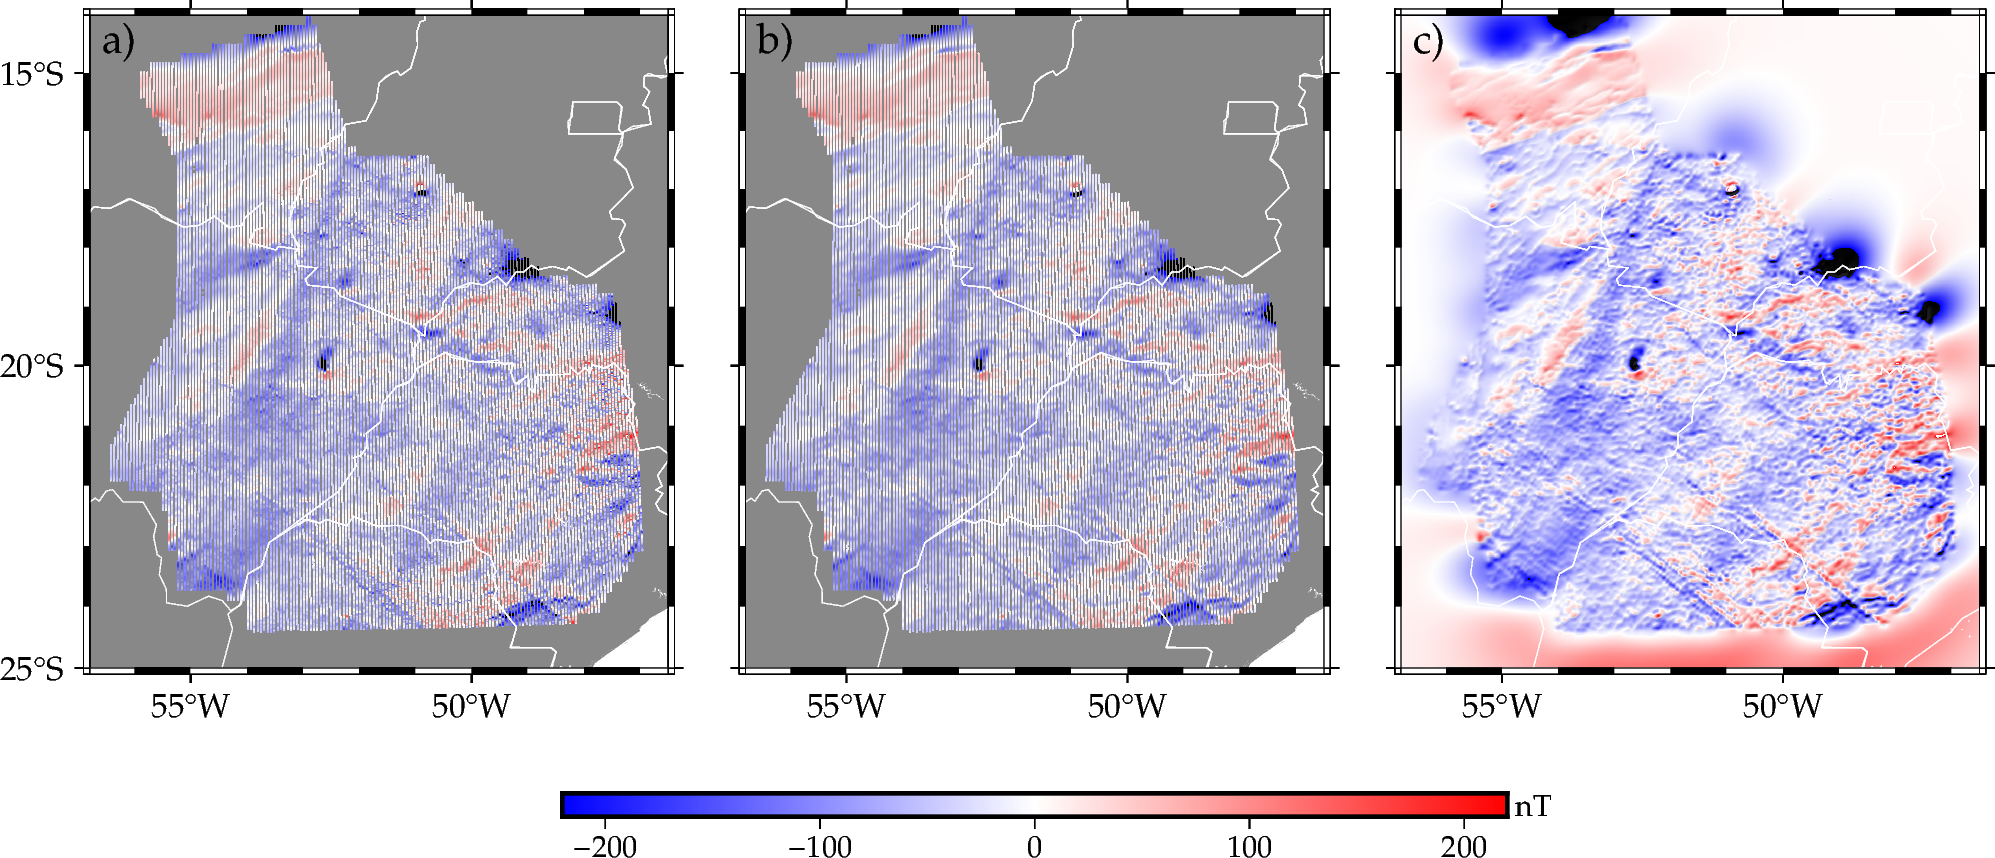

In [19]:
region = [-56.8, -46.5, -25, -14]
scale = 220
fig = pygmt.Figure()

with pygmt.config(FONT="10p,Palatino-Roman",
    FONT_ANNOT="8p,Palatino-Roman",
    FONT_ANNOT_PRIMARY="8p,Palatino-Roman",
    FONT_ANNOT_SECONDARY="8p,Palatino-Roman",
    MAP_FRAME_WIDTH="1.5p",
    MAP_TITLE_OFFSET="-2p", ):

    pygmt.makecpt(cmap="polar", series=[-scale, scale])

    with fig.subplot(nrows=1,
            ncols=3,
            figsize=("16c", "6c"),
            autolabel="+jTL+o0.1/0.3c",
            margins='0.2c/.2c',
            sharex="b",
            sharey="l"):
        
        with fig.set_panel(panel=0):

            fig.coast(
                    land="#888888",
                    region = region,
                    projection="M?",
                )

            fig.plot(
                    x=df.LONGITUDE,
                    y=df.LATITUDE,
                    fill=df.MAGIGRF,
                    style="c0.01c",
                    cmap=True
            )

            fig.plot(
                data=brasil_reduc.geometry,
                pen=".2p,white",
                fill=None,
                projection="M?",
                frame=["a42f"]
            )


        with fig.set_panel(panel=1):

            fig.coast(
                    land="#888888",
                    region = region,
                    projection="M?",
            )
            
            fig.plot(
                x=coordinates[0],
                y=coordinates[1],
                fill=tfa_scatter,
                style="c0.01c",
                projection="M?",
                cmap=True
            )

            fig.plot(
                data=brasil_reduc.geometry,
                pen=".2p,white",
                fill=None,
                projection="M?",
                frame=["a42f"]
            )

        with fig.set_panel(panel=2):

            fig.coast(
                land="#888888",
                region = region,
                projection="M?",
            )

            fig.grdimage(
            grid=total_field_anomaly_predicted,
            region=region,
            projection="M?",  
            cmap=True,
            shading="+nt0.15",
            )       

            fig.plot(
                data=brasil_reduc.geometry,
                pen=".2p,white",
                fill=None,
                projection="M?",
                frame=["a42f"]
            )


pygmt.config(FONT_ANNOT_PRIMARY="10p,Palatino-Roman", FONT_ANNOT_SECONDARY="10p,Palatino-Roman")
fig.colorbar(position="JBC+w8/0.2c+h", frame=["y+lnT", 'a'])
fig.show(width=7000)
fig.savefig(fname='../paper/figures/comparison-blocreduce-00023deg.jpeg',transparent=False)

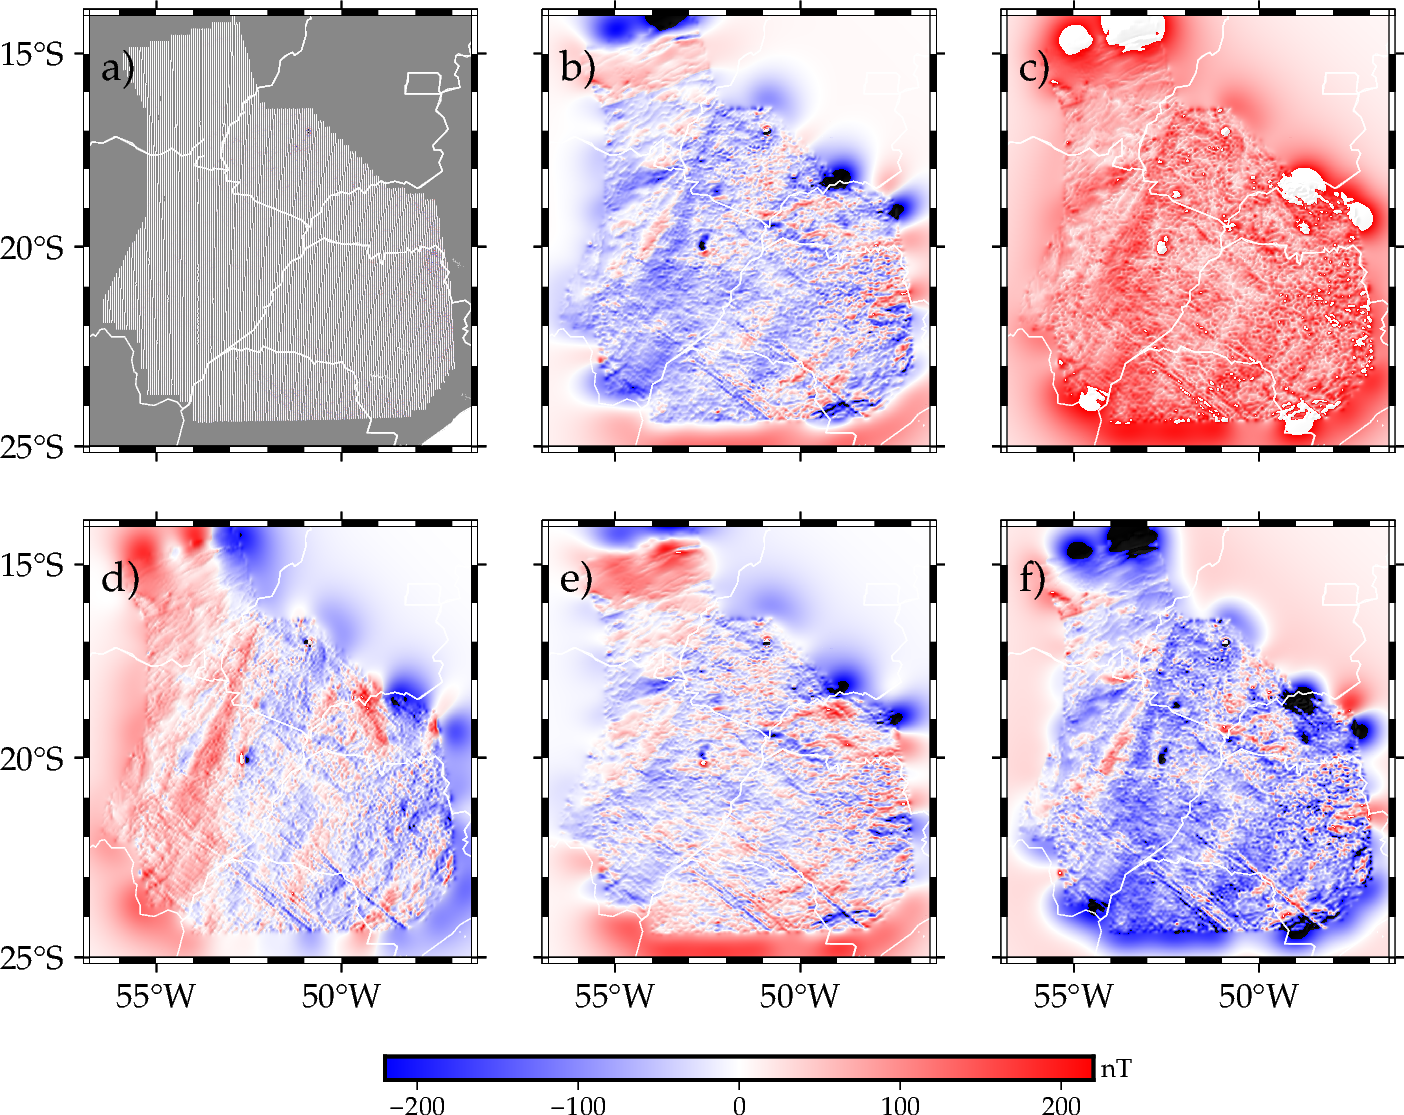

In [31]:
region = [-56.8, -46.5, -25, -14]
scale = 220
fig = pygmt.Figure()

with pygmt.config(FONT="10p,Palatino-Roman",
    FONT_ANNOT="8p,Palatino-Roman",
    FONT_ANNOT_PRIMARY="8p,Palatino-Roman",
    FONT_ANNOT_SECONDARY="8p,Palatino-Roman",
    MAP_FRAME_WIDTH="1.5p",
    MAP_TITLE_OFFSET="-2p", ):

    pygmt.makecpt(cmap="polar", series=[-scale, scale])

    with fig.subplot(nrows=2,
            ncols=3,
            figsize=("11c", "8c"),
            autolabel="+jTL+o0.1/0.3c",
            margins='0.2c/.2c',
            sharex="b",
            sharey="l"):
        
        with fig.set_panel(panel=0):

            fig.coast(
                    land="#888888",
                    region = region,
                    projection="M?",
                )

            fig.plot(
                    x=coordinates[0],
                    y=coordinates[1],
                    fill= residuals_scatter,
                    style="c0.001c",
                    cmap=True
            )

            fig.plot(
                data=brasil_reduc.geometry,
                pen=".2p,white",
                fill=None,
                projection="M?",
                frame=["a42f"]
            )


        with fig.set_panel(panel=1):

            fig.coast(
                    land="#888888",
                    region = region,
                    projection="M?",
            )
            
            fig.grdimage(
            grid=total_field_anomaly_predicted,
            region=region,
            projection="M?",  
            cmap=True,
            shading="+nt0.15",
            )     

            fig.plot(
                data=brasil_reduc.geometry,
                pen=".2p,white",
                fill=None,
                projection="M?",
                frame=["a42f"]
            )

        with fig.set_panel(panel=2):

            fig.coast(
                land="#888888",
                region = region,
                projection="M?",
            )

            fig.grdimage(
            grid=norm_b_predicted,
            region=region,
            projection="M?",  
            cmap=True,
            shading="+nt0.15",
            )       

            fig.plot(
                data=brasil_reduc.geometry,
                pen=".2p,white",
                fill=None,
                projection="M?",
                frame=["a42f"]
            )

        with fig.set_panel(panel=3):

            fig.coast(
                land="#888888",
                region = region,
                projection="M?",
            )

            fig.grdimage(
            grid=b_predicted["be"],
            region=region,
            projection="M?",  
            cmap=True,
            shading="+nt0.15",
            )       

            fig.plot(
                data=brasil_reduc.geometry,
                pen=".2p,white",
                fill=None,
                projection="M?",
                frame=["a42f"]
            )

        with fig.set_panel(panel=4):

            fig.coast(
                land="#888888",
                region = region,
                projection="M?",
            )

            fig.grdimage(
            grid=b_predicted["bn"],
            region=region,
            projection="M?",  
            cmap=True,
            shading="+nt0.15",
            )       

            fig.plot(
                data=brasil_reduc.geometry,
                pen=".2p,white",
                fill=None,
                projection="M?",
                frame=["a42f"]
            )

        with fig.set_panel(panel=5):

            fig.coast(
                land="#888888",
                region = region,
                projection="M?",
            )

            fig.grdimage(
            grid=b_predicted["bu"],
            region=region,
            projection="M?",  
            cmap=True,
            shading="+nt0.15",
            )       

            fig.plot(
                data=brasil_reduc.geometry,
                pen=".2p,white",
                fill=None,
                projection="M?",
                frame=["a42f"]
            )


pygmt.config(FONT_ANNOT_PRIMARY="10p,Palatino-Roman", FONT_ANNOT_SECONDARY="10p,Palatino-Roman")
fig.colorbar(position="JBC+w6/0.2c+h", frame=["y+lnT", 'a'])
fig.show(width=7000)
fig.savefig(fname='../paper/figures/real-data-tfa-norm-bcomponents.jpeg',transparent=False)